In [1]:
import shutil
from pathlib import Path
from typing import Any

import lancedb
from lancedb.rerankers import ColbertReranker

from rag_app import add_data, application, get_user_query

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
LANCE_URI = "lance/rag/"
if Path(LANCE_URI).exists():
    shutil.rmtree(LANCE_URI)

In [3]:
lance_db = lancedb.connect(uri=LANCE_URI)
reranker = ColbertReranker("answerdotai/answerai-colbert-small-v1")
data_path = "rag_data"

In [4]:
table_descriptions = add_data(lance_db=lance_db, data_path=data_path)

/home/hamza/dev/dreamai/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [5]:
table_descriptions

[TableDescription(name='Soccer', description='This database serves as a comprehensive guide to soccer, encompassing basic rules, gameplay mechanics, player positions, popular formations, and key terms. It offers an in-depth understanding of the sport, from its fundamentals to advanced tactics and strategies.'),
 TableDescription(name='Finance', description='This database provides comprehensive information on personal finance, covering a wide range of topics from budgeting and saving to investing, insurance, and estate planning. It includes detailed explanations of concepts, practical strategies, and real-world examples to guide individuals in making informed financial decisions and achieving their goals.')]

In [6]:
app = application(
    db=lance_db, reranker=reranker, table_descriptions=table_descriptions, has_web=True
)

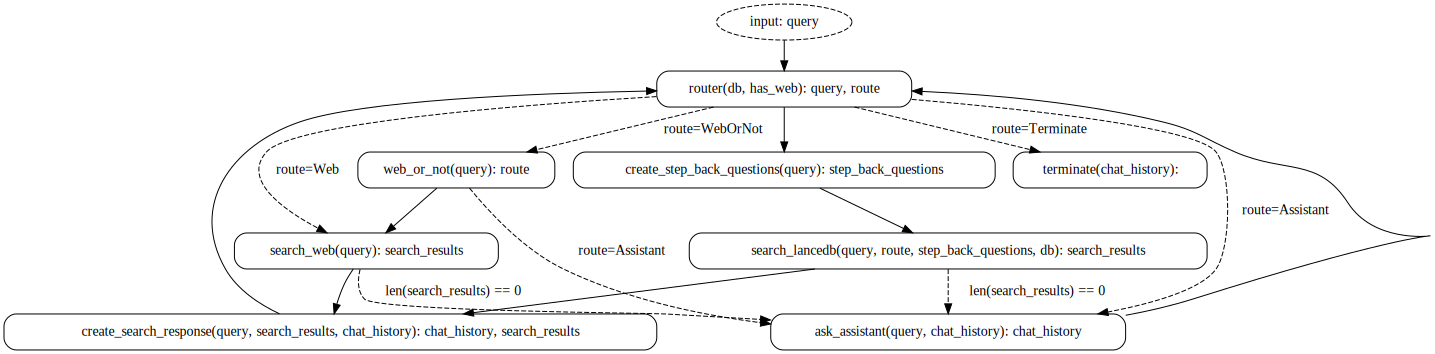

In [7]:
app.visualize(
    output_file_path="statemachine",
    include_conditions=True,
    include_state=True,
    format="png",
)

In [8]:
inputs = {"query": get_user_query()}
while True:
    action, result, state = app.step(inputs=inputs)  # type:ignore
    print(f"\nRESULT: {result}\n")
    if action.name == "terminate":
        break
    elif action.name in ["ask_assistant", "create_search_response"]:
        inputs["query"] = get_user_query()


RESULT: {'route': 'Soccer'}


RESULT: {'step_back_questions': ['What are the rules and regulations that govern the awarding of penalties in a specific sport or context? ', 'What situations or actions typically result in penalties being assessed, and how do these vary across different sports or rulesets?']}



/home/hamza/dev/dreamai/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



RESULT: {'search_results': ['## 6. Fouls and Misconduct\nUnderstanding fouls and misconduct is crucial in soccer. These rules ensure fair play\nand player safety.\n1. **Direct Free Kick Fouls**:\n  - Kicking or attempting to kick an opponent\n  - Tripping or attempting to trip an opponent\n  - Jumping at an opponent\n  - Charging an opponent\n  - Striking or attempting to strike an opponent\n  - Pushing an opponent\n  - Tackling an opponent to gain possession of the ball, making contact with the\nopponent before touching the ball\n  - Holding an opponent\n  - Spitting at an opponent\n  - Handling the ball deliberately (except for the goalkeeper within their penalty\narea)\n2. **Indirect Free Kick Fouls', '## 2. Basic Rules of the Game\nModern soccer is governed by 17 laws, as established by the International Football\nAssociation Board (IFAB). Here are the fundamental rules that every beginner should\nknow:\n1. **Match Duration**: A standard match consists of two 45-minute halves, wit